In [3]:
# Amazon Laptop Scraping
# import libraries
import re
import requests
from bs4 import BeautifulSoup
import pandas as pd


%pip install beautifulsoup4 requests pandas

# take the url of the page
url = "https://www.amazon.in/s?k=laptops&crid=3R9WE5K6F9ZLA&sprefix=laptops%2Caps%2C522&ref=nb_sb_noss_2"
# create the request header

headers = {
    "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/151.0.0.0 Safari/537.36"
}

# send the request
response = requests.get(url, headers=headers)

# check if the request was successful
response.status_code
# show the content of the page
response.content
# beautiful soup object

bs = BeautifulSoup(response.content, "html.parser")
print(bs)
# create the empty list to store the data
Data = []
list_data = []

for page in range(1, 30):
    params = {"k": "laptops", "page": page}
    response = requests.get(url, headers=headers, params=params, timeout=30)
    response.raise_for_status()
    bs = BeautifulSoup(response.text, "html.parser")

    product_containers = bs.select('div[data-component-type="s-search-result"]')

    for product in product_containers:

        title_tag = product.select_one("h2 span")
        if not title_tag:
            continue

        #Step 1:Extract the Title
        title = title_tag.get_text(" ", strip=True)

        # Step 2: Extract the Price
        price_tag = product.select_one("span.a-price-whole")

        # Step 3: Extract the Rating
        rating_tag = product.select_one("span.a-size-small.a-color-base")
        match = re.match(r"([A-Za-z]+)", title)


        #Step 5: Extract the Brand Name
        brand = match.group(1) if match else "Unknown"
        
        #Step 6: Extract the RAM
        match = re.search(r"(\d+GB|RAM\s*(\d+GB)?|DDR\d?\s*(\d+GB)?|LPDDR\d?\s*(\d+GB)?)", title, re.IGNORECASE)
        ram = match.group(1) if match else "N/A"

        #Step 7: Extract the Storage 
        match = re.search(r"(\d+)\s*(GB|TB)\s*(?:SSD|Storage|HDD)", title, re.IGNORECASE)
        ssd_storage = f"{match.group(1)}{match.group(2)}" if match else "N/A"

        #Step 8: Extract the Color
        match = re.search(r"\b(Black|White|Silver|Gray|Grey|Red|Blue|Green|Yellow|Pink|Purple|Gold|Bronze|Rose Gold|Indigo|Glacier)\b", title, re.IGNORECASE)
        color = match.group(1) if match else "N/A"
       
        # Step 9: Extract the processor information
        # Step 7: Extract the processor (Intel, AMD, Apple M/A chip, Snapdragon, MediaTek, etc)
        processor = "N/A"
        # Try to match Apple M series (M1, M2, M3, M4, M5, etc.)
        match = re.search(r"Apple\s+M(\d+)", title, re.IGNORECASE)
        if match:
            processor = f"Apple M{match.group(1)}"
        else:
            # Try to match Apple A series (A18, A17, A16, etc.)
            match = re.search(r"Apple\s+A(\d+)", title, re.IGNORECASE)
            if match:
                processor = f"Apple A{match.group(1)}"
            else:
                # Try other processor keywords
                processor_keywords = ["Intel", "AMD", "Snapdragon", "MediaTek", "Celeron"]
                for keyword in processor_keywords:
                    if re.search(rf"\b{keyword}\b", title, re.IGNORECASE):
                        processor = keyword
                        break

        # Append the extracted data to the list
        list_data.append({
            "title": title,
            "price": price_tag.get_text(strip=True) if price_tag else "N/A",
            "rating": rating_tag.get_text(strip=True) if rating_tag else "N/A",
            "brand": brand,
            "ram": ram,
            "storage": ssd_storage,
            "color": color,
            "processor": processor
            })

# display the data item 

for item in list_data:
    print(f"Title: {item['title']}")
    print(f"Price: {item['price']}")
    print(f"Rating: {item['rating']}")
    print(f"Brand: {item['brand']}")
    print(f"RAM: {item['ram']}")
    print(f"Storage: {item['storage']}")
    print(f"Color: {item['color']}")
    print(f"Processor: {item['processor']}")

    print("-" * 50)
# check the length of the data
print(f"Total number of laptops scraped: {len(list_data)}")
# display the match
print(brand)
df = pd.DataFrame(list_data)
df

import pandas as pd

raw_df = pd.DataFrame(list_data)

raw_df.to_csv(
    r"C:\Users\hp\OneDrive\Desktop\web_scraping_folder\amazon_raw_data.csv",
    index=False
)
df.head()
clean_df = df.copy()
clean_df.info()
clean_df.isnull().sum()
clean_df.duplicated().sum()
# clean price column 
clean_df["price"]=(
    clean_df["price"]
    .astype(str)
    .str.replace(",","",regex=False)
)
#convert price to numeric 
clean_df["price"]=pd.to_numeric(
    clean_df["price"],
    errors="coerce"
)
# fill missing with  the median price 
clean_df["price"]=clean_df["price"].fillna(clean_df["price"].median())
clean_df["price"].head()



clean_df["price"].head()
#clean rating 
#convert rating to numeric 
clean_df["rating"]=pd.to_numeric(
    clean_df["rating"],
    errors="coerce"
    )
clean_df["rating"].head()
# Handle missing/invalid ratings

# Convert rating column to numeric
clean_df["rating"] = pd.to_numeric(
    clean_df["rating"],
    errors="coerce"
)

# Fill missing/invalid ratings with median
clean_df["rating"] = clean_df["rating"].fillna(
    clean_df["rating"].median()
)

clean_df["ram"].value_counts(dropna=False)

# replace N/A values with unknown 
clean_df["ram"]=clean_df["ram"].replace("N/A","Unknown")
clean_df["ram"].value_counts(dropna=False)

# Replace RAM type values with Unknown
clean_df["ram"] = clean_df["ram"].replace(
    ["DDR4", "DDR5", "DDR7", "LPDDR4", "LPDDR5"],
    "Unknown"
)

# Check RAM values
print(clean_df["ram"].value_counts())
#clean processor 
clean_df["processor"]=clean_df["processor"].replace(
    "N/A","Unknown"
)

#clean space and capitalization 
clean_df["processor"]=(
    clean_df["processor"]
    .astype(str)
    .str.strip()
    .str.title()
)
clean_df["processor"].value_counts()
# clean text columns
text_columns = [
    "title",
    "brand",
    "ram",
    "storage",
    "color",
    "processor",
]


for col in text_columns:
    clean_df[col] = (
        clean_df[col]
        .astype(str)
        .str.strip()
    )

# Replace only RAM with Unknown
clean_df["ram"] = clean_df["ram"].replace("RAM", "Unknown")

clean_df["ram"].value_counts()
# Convert TB values to GB in the same storage column
def convert_storage(value):
    value = str(value).strip().upper()

    if "TB" in value:
        number = float(value.replace("TB", "").strip())
        return f"{int(number * 1024)}GB"

    return value


# Apply conversion to the existing storage column
clean_df["storage"] = clean_df["storage"].apply(convert_storage)

# Check the result
clean_df["storage"].value_counts()



# Replace N/A values with Unknown
clean_df = clean_df.replace("N/A", "Unknown")

# Fill actual missing values with Unknown
clean_df = clean_df.fillna("Unknown")

# Check for missing values
print(clean_df.isnull().sum())
# remove duplicate rows 
# remove duplicate records 
clean_df= clean_df.drop_duplicates()
clean_df.duplicated().sum()
# check the cleaned dataset 
clean_df.info()
clean_df.head(10)
clean_df.to_csv(
    r"C:\Users\hp\OneDrive\Desktop\web_scraping_folder\amz2_cleaned_data.csv",
    index=False
)
import os

path = r"C:\Users\hp\OneDrive\Desktop\web_scraping_folder\laptop_cleaned_data.csv"

print(os.path.exists(path))





Note: you may need to restart the kernel to use updated packages.
<!DOCTYPE html>
<html class="a-no-js" data-19ax5a9jf="dingo" lang="en-in"><!-- sp:feature:head-start -->
<head><script>var aPageStart = (new Date()).getTime();</script><meta charset="utf-8"/>
<!-- sp:end-feature:head-start -->
<!-- sp:feature:csm:head-open-part1 -->
<script type="text/javascript">var ue_t0=ue_t0||+new Date();</script>
<!-- sp:end-feature:csm:head-open-part1 -->
<!-- sp:feature:cs-optimization -->
<meta content="on" http-equiv="x-dns-prefetch-control"/>
<link crossorigin="" href="https://images-eu.ssl-images-amazon.com" rel="preconnect"/>
<link crossorigin="" href="https://m.media-amazon.com" rel="preconnect"/>
<!-- sp:end-feature:cs-optimization -->
<!-- sp:feature:csm:head-open-part2 -->
<script type="text/javascript">
window.ue_ihb = (window.ue_ihb || window.ueinit || 0) + 1;
if (window.ue_ihb === 1) {

var ue_csm = window,
    ue_hob = +new Date();
(function(d){var e=d.ue=d.ue||{},f=Date.now||function

# EDA

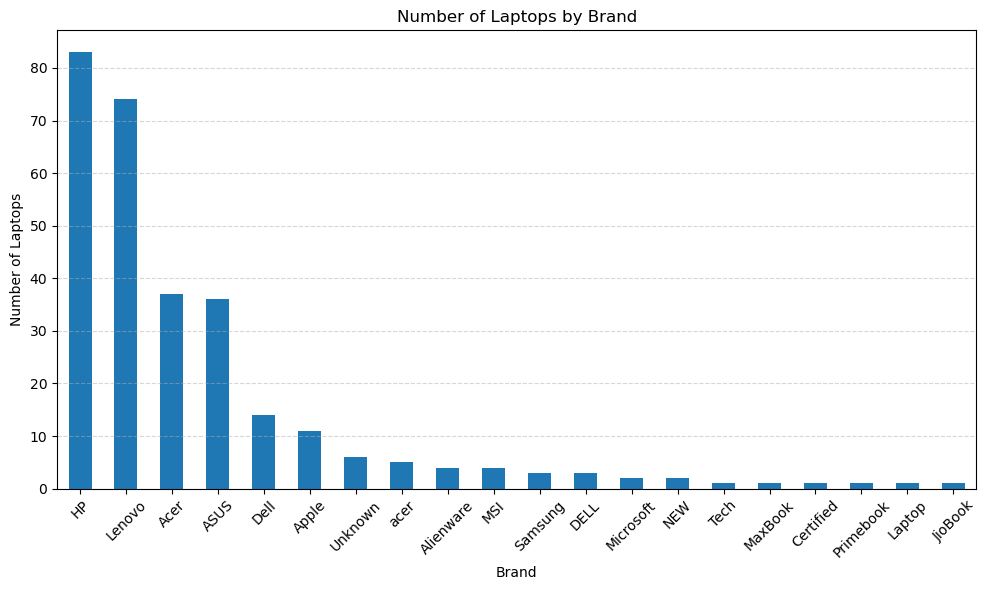

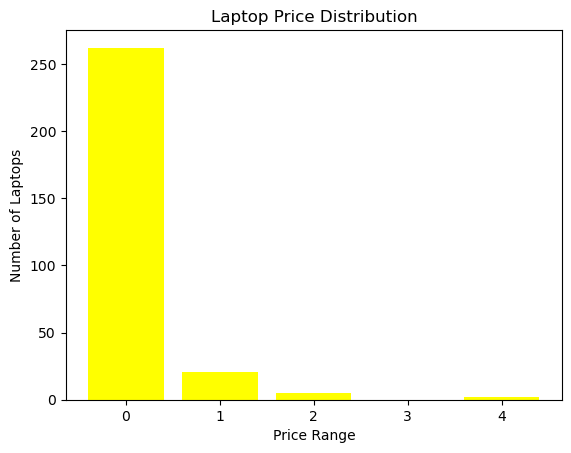

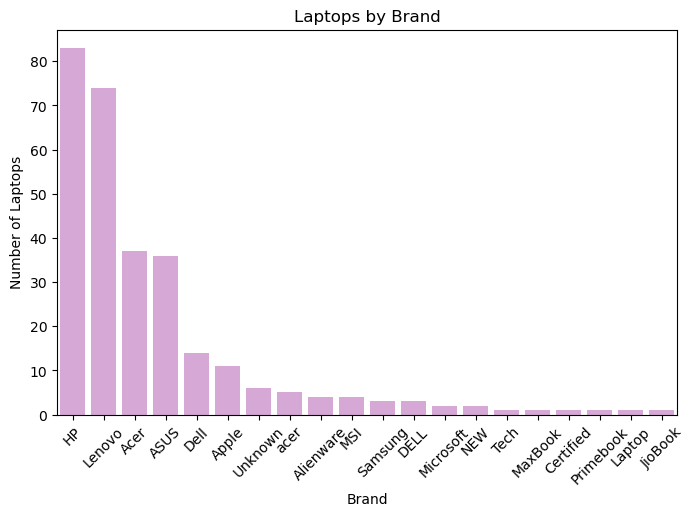

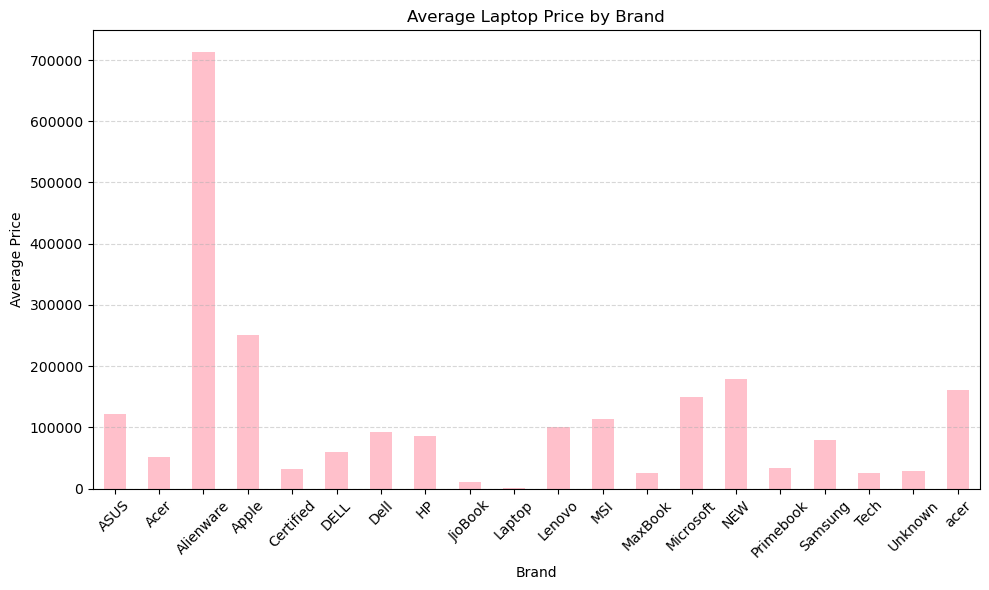

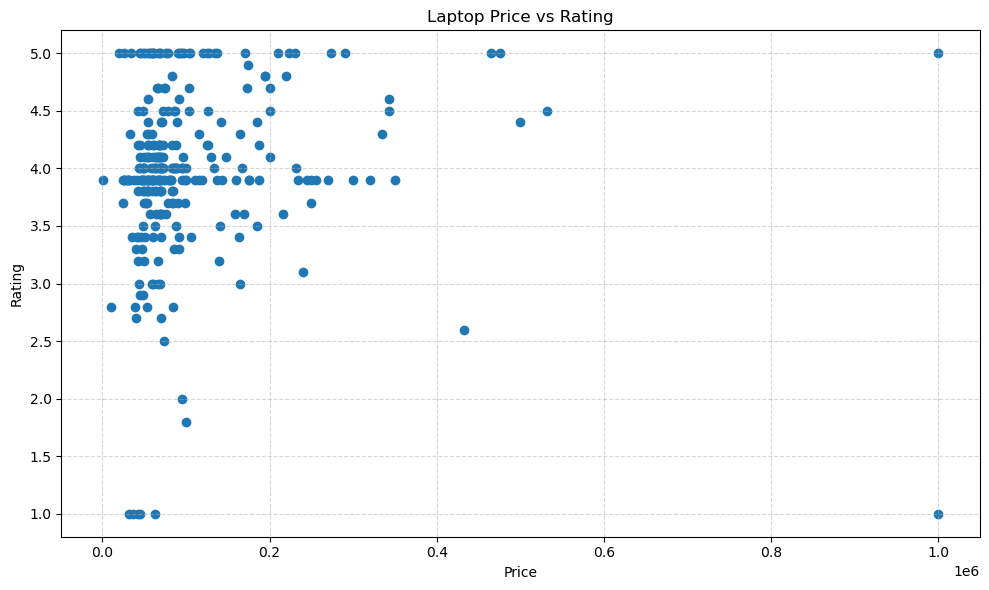

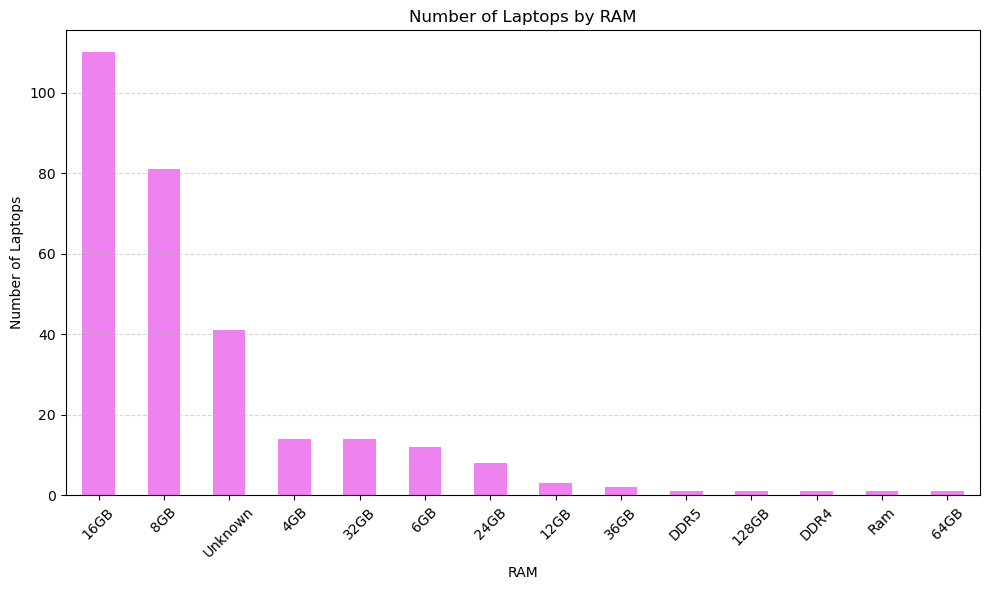

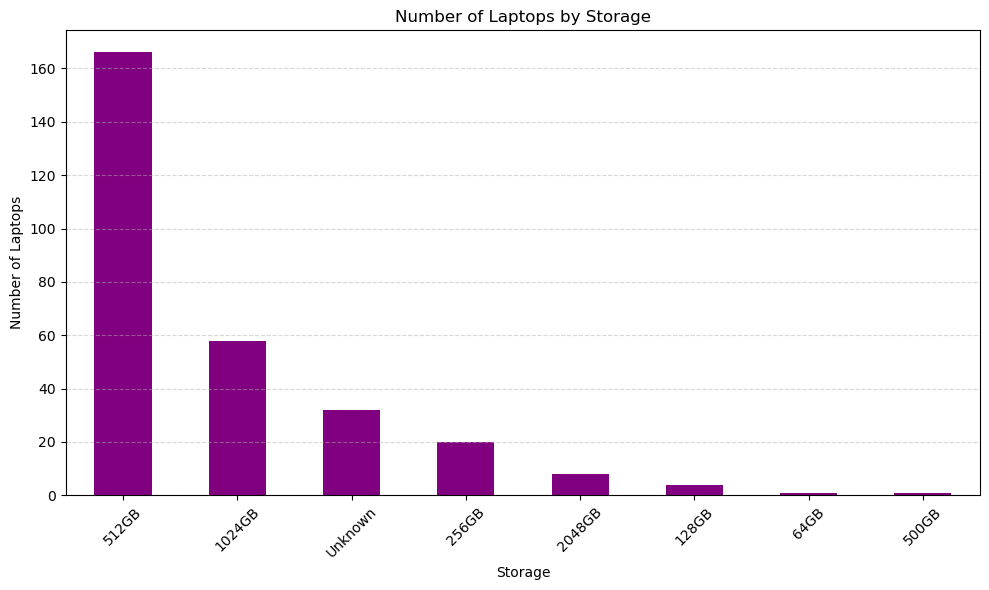

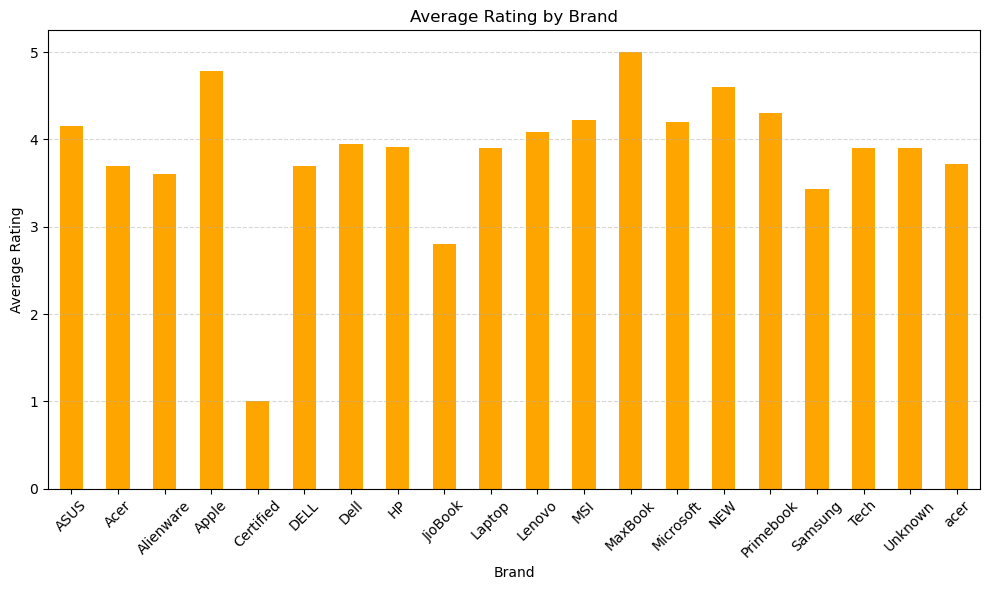

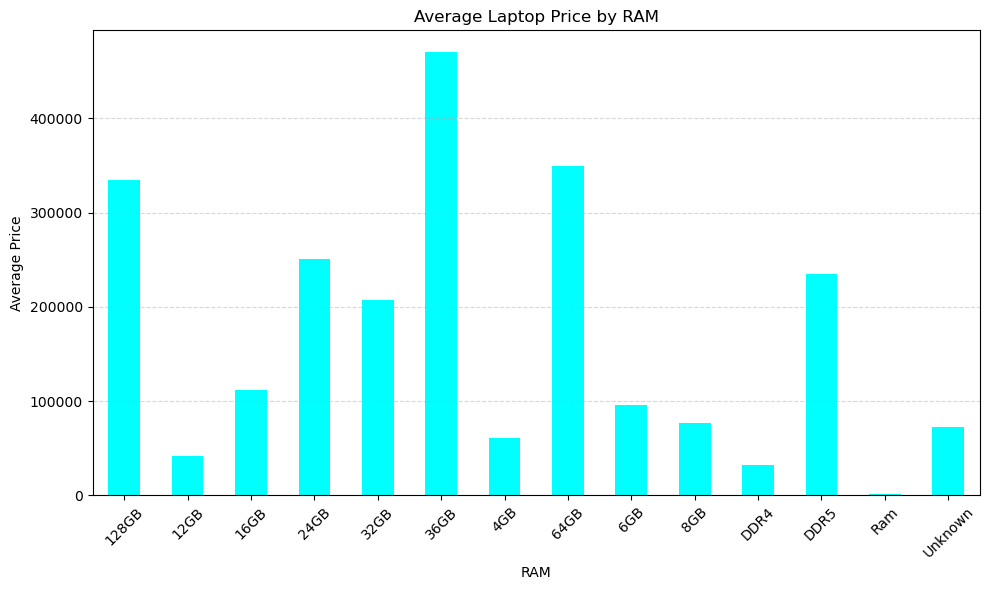

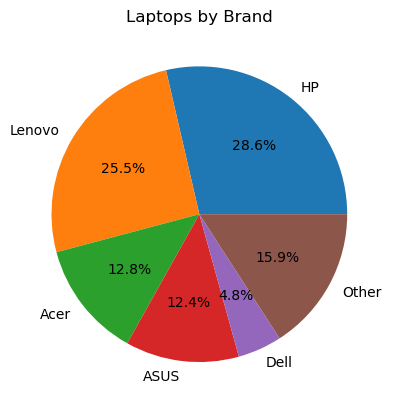

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

#  load cleaned data 
clean_df=pd.read_csv("amz2_cleaned_data.csv")

#display first five rows 
clean_df.head()
# CHART 1: NUMBER OF LAPTOPS BY BRAND

# Count the number of laptops for each brand
brand_counts = clean_df["brand"].value_counts()

# Create the bar chart
plt.figure(figsize=(10, 6))

brand_counts.plot(kind="bar")

# Add title and labels
plt.title("Number of Laptops by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Laptops")

# Rotate brand names for better readability
plt.xticks(rotation=45)

# Add grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

# Explanation:
# This bar chart shows the number of laptop products available for each brand
# in the scraped dataset. It helps identify which brands have the highest
# representation in the collected laptop listings.




# CHART 2: LAPTOP PRICE RANGE

# Get price values using NumPy
prices = np.array(clean_df["price"])

# Create price ranges
price_range = np.histogram(prices, bins=5)

# Create bar chart
plt.bar(
    range(5),
    price_range[0],
    color="yellow"
)

# Add title
plt.title("Laptop Price Distribution")

# Add labels
plt.xlabel("Price Range")
plt.ylabel("Number of Laptops")

# Show chart
plt.show()

# Explanation:
# This chart shows the number of laptops in different price ranges.



# CHART 3: LAPTOPS BY BRAND

# Count laptops by brand
brand_counts = clean_df["brand"].value_counts()

# Create bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=brand_counts.index, y=brand_counts.values,color="plum")

# Add title
plt.title("Laptops by Brand")

# Add labels
plt.xlabel("Brand")
plt.ylabel("Number of Laptops")

# Rotate brand names
plt.xticks(rotation=45)

# Show chart
plt.show()

# Explanation:
# This chart shows the number of laptops available for each brand.



# CHART 4: AVERAGE LAPTOP PRICE BY BRAND

# Calculate the average price for each brand
average_price = clean_df.groupby("brand")["price"].mean()

# Create the bar chart
plt.figure(figsize=(10, 6))

average_price.plot(kind="bar",color="pink")

# Add title and labels
plt.title("Average Laptop Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")

# Rotate brand names for better readability
plt.xticks(rotation=45)

# Add grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

# Explanation:
# This bar chart shows the average price of laptops for each brand.
# It helps compare the pricing levels of different laptop brands.




# CHART 5: LAPTOP PRICE VS RATING

# Create the scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(clean_df["price"], clean_df["rating"])

# Add title and labels
plt.title("Laptop Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")

# Add grid lines
plt.grid(True, linestyle="--", alpha=0.5)

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

# Explanation:
# This scatter plot shows the relationship between laptop price and rating.
# It helps observe whether expensive laptops generally have higher ratings.



# CHART 6: NUMBER OF LAPTOPS BY RAM

# Count the number of laptops for each RAM configuration
ram_counts = clean_df["ram"].value_counts()

# Create the bar chart
plt.figure(figsize=(10, 6))

ram_counts.plot(kind="bar",color="violet")

# Add title and labels
plt.title("Number of Laptops by RAM")
plt.xlabel("RAM")
plt.ylabel("Number of Laptops")

# Rotate RAM values for better readability
plt.xticks(rotation=45)

# Add grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

# Explanation:
# This bar chart shows the number of laptops available for each RAM configuration.
# It helps identify the most commonly available RAM option in the dataset.



# CHART 7: NUMBER OF LAPTOPS BY STORAGE

# Count the number of laptops for each storage option
storage_counts = clean_df["storage"].value_counts()

# Create the bar chart
plt.figure(figsize=(10, 6))

storage_counts.plot(kind="bar",color="purple")

# Add title and labels
plt.title("Number of Laptops by Storage")
plt.xlabel("Storage")
plt.ylabel("Number of Laptops")

# Rotate storage names for better readability
plt.xticks(rotation=45)

# Add grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

# Explanation:
# This chart shows the number of laptops available for each storage option.



# CHART 8: AVERAGE RATING BY BRAND

# Calculate the average rating for each brand
average_rating = clean_df.groupby("brand")["rating"].mean()

# Create the bar chart
plt.figure(figsize=(10, 6))

average_rating.plot(kind="bar",color="orange")

# Add title and labels
plt.title("Average Rating by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Rating")

# Rotate brand names for better readability
plt.xticks(rotation=45)

# Add grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

# Explanation:
# This bar chart shows the average rating of laptops for each brand.
# It helps compare the customer ratings of different laptop brands.


# CHART 9: AVERAGE LAPTOP PRICE BY RAM

# Calculate the average price for each RAM configuration
average_price_ram = clean_df.groupby("ram")["price"].mean()

# Create the bar chart
plt.figure(figsize=(10, 6))

average_price_ram.plot(kind="bar",color="cyan")

# Add title and labels
plt.title("Average Laptop Price by RAM")
plt.xlabel("RAM")
plt.ylabel("Average Price")

# Rotate RAM values for better readability
plt.xticks(rotation=45)

# Add grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show()

# Explanation:
# This bar chart shows the average laptop price for different RAM configurations.
# It helps understand how laptop prices vary with different RAM options.



# CHART 10 : LAPTOPS BY BRAND

# Count laptops by brand
brand_counts = clean_df["brand"].value_counts()

# Take top 5 brands
top_brands = brand_counts.head(5)

# Add remaining brands as Other
top_brands["Other"] = brand_counts.iloc[5:].sum()

# Create pie chart
plt.pie(
    top_brands,
    labels=top_brands.index,
    autopct="%1.1f%%"
)

# Add title
plt.title("Laptops by Brand")

# Show chart
plt.show()

# Explanation:
# This pie chart shows the percentage of laptops for the top 5 brands and other brands.
